In [1]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


                         date  montant  quantite  heure type_transaction  \
0  2024-03-22 20:12:15.135135   354627        77     16    remboursement   
1  2024-09-16 18:35:40.540540    46340        64     12            achat   
2  2024-03-09 16:31:42.702702   356664        38     13    remboursement   
3  2024-09-16 09:49:32.972972   267070        55     16            achat   
4  2024-08-13 10:19:49.189189   403422        23     11            vente   

   is_anomalie  
0            0  
1            0  
2            0  
3            0  
4            0  

Distribution : is_anomalie
0    1000
1      50
Name: count, dtype: int64


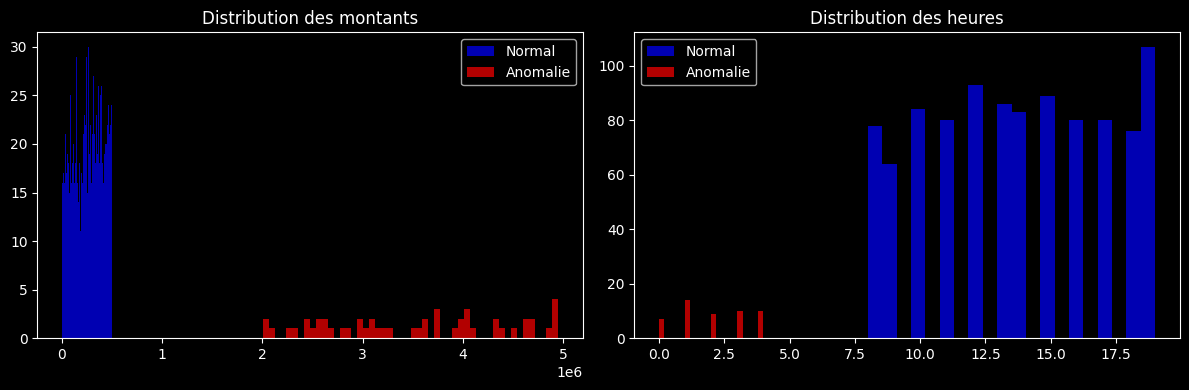

In [5]:

# Charger le dataset
df = pd.read_csv('/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/datasets/klaaro_dataset.csv')

# Afficher les premières lignes
print(df.head())
print(f"\nDistribution : {df['is_anomalie'].value_counts()}")

# Visualiser les montants
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df[df['is_anomalie']==0]['montant'], bins=50, color='blue', alpha=0.7, label='Normal')
plt.hist(df[df['is_anomalie']==1]['montant'], bins=50, color='red', alpha=0.7, label='Anomalie')
plt.legend()
plt.title('Distribution des montants')

plt.subplot(1, 2, 2)
plt.hist(df[df['is_anomalie']==0]['heure'], bins=20, color='blue', alpha=0.7, label='Normal')
plt.hist(df[df['is_anomalie']==1]['heure'], bins=20, color='red', alpha=0.7, label='Anomalie')
plt.legend()
plt.title('Distribution des heures')

plt.tight_layout()
plt.show()

In [6]:
# Encoder le type_transaction
le = LabelEncoder()
df['type_transaction_encoded'] = le.fit_transform(df['type_transaction'])

# Features pour le modèle
features = ['montant', 'quantite', 'heure', 'type_transaction_encoded']
X = df[features]
y = df['is_anomalie']

# Entraîner Isolation Forest
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
model.fit(X)

# Prédictions
predictions = model.predict(X)
# Isolation Forest retourne -1 pour anomalie et 1 pour normal
predictions = [1 if p == -1 else 0 for p in predictions]

print(classification_report(y, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       0.94      1.00      0.97        50

    accuracy                           1.00      1050
   macro avg       0.97      1.00      0.98      1050
weighted avg       1.00      1.00      1.00      1050


Confusion Matrix:
[[997   3]
 [  0  50]]


SAUVEGARDE DU MODELE

In [8]:
import joblib
import os

os.makedirs('ml/models', exist_ok=True)

# Sauvegarder le modèle et le label encoder
joblib.dump(model, '/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/isolation_forest.pkl')
joblib.dump(le, '/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/models/label_encoder.pkl')

print("Modèle sauvegardé !")

Modèle sauvegardé !
